In [1]:
import sys

!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import sys

!{sys.executable} -m pip install xgboost lightgbm catboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("All libraries imported successfully")

All libraries imported successfully


In [5]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (1639424, 7)
Test Shape: (409856, 7)


In [6]:
train.head()

,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1639424 entries, 0 to 1639423
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1639424 non-null  datetime64[ns]
 1   X1      1639424 non-null  float64       
 2   X2      1639424 non-null  float64       
 3   X3      1639424 non-null  float64       
 4   X4      1639424 non-null  float64       
 5   X5      1639424 non-null  float64       
 6   target  1639424 non-null  str           
dtypes: datetime64[ns](1), float64(5), str(1)
memory usage: 89.1 MB


In [8]:
train.isnull().sum()

Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64

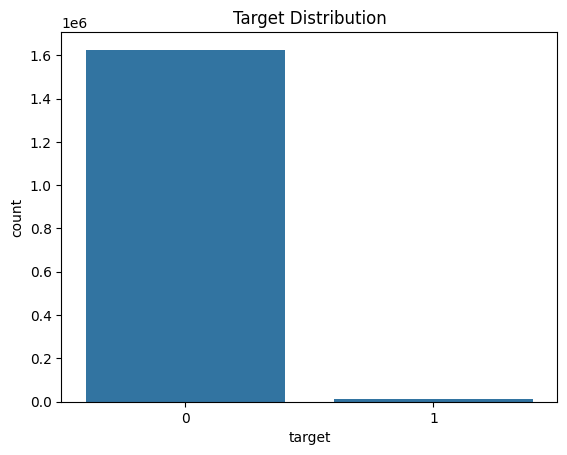

In [9]:
sns.countplot(x='target', data=train)

plt.title("Target Distribution")

plt.show()

In [10]:
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

print("Date converted")

Date converted


In [11]:
for df in [train, test]:

    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['hour'] = df['Date'].dt.hour
    df['dayofweek'] = df['Date'].dt.dayofweek

print("Date features created")

Date features created


In [12]:
train.drop('Date', axis=1, inplace=True)
test.drop('Date', axis=1, inplace=True)

print("Date column removed")

Date column removed


In [13]:
train = train.fillna(train.select_dtypes(include=np.number).median())

test = test.fillna(test.select_dtypes(include=np.number).median())

print("Missing values handled successfully")

Missing values handled successfully


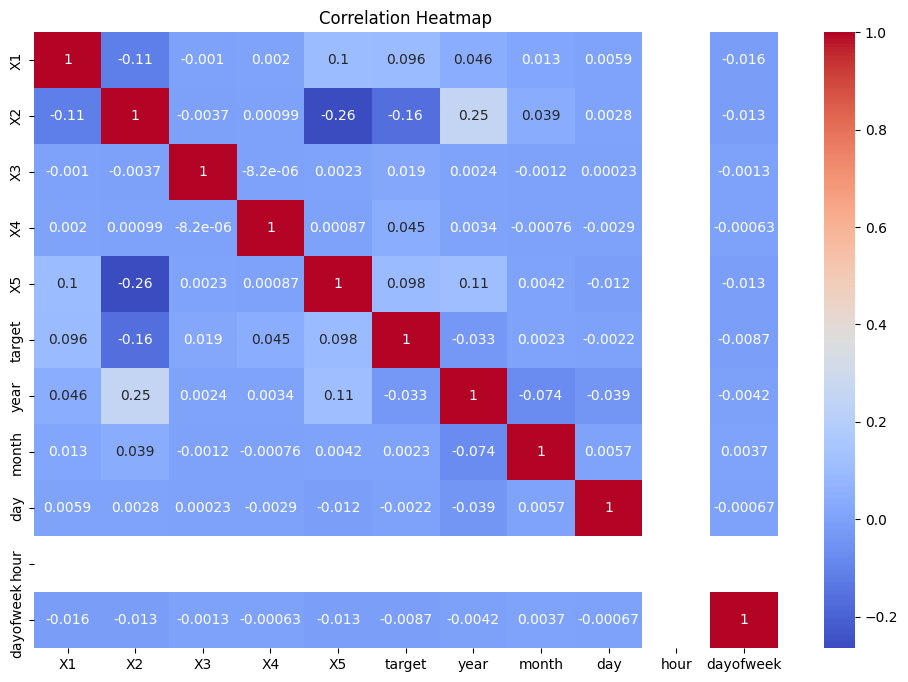

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(train.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [15]:
sensor_cols = ['X1', 'X2', 'X3', 'X4', 'X5']

for df in [train, test]:

    # Statistical Features
    df['sensor_mean'] = df[sensor_cols].mean(axis=1)
    df['sensor_std'] = df[sensor_cols].std(axis=1)
    df['sensor_min'] = df[sensor_cols].min(axis=1)
    df['sensor_max'] = df[sensor_cols].max(axis=1)

    # Interaction Features
    df['X1_X2'] = df['X1'] * df['X2']
    df['X3_X4'] = df['X3'] * df['X4']

    # Ratio Feature
    df['X5_div_X1'] = df['X5'] / (df['X1'] + 1e-5)

print("Feature engineering completed")

Feature engineering completed


In [16]:
for df in [train, test]:

    df['X1_minus_X2'] = df['X1'] - df['X2']

    df['X2_minus_X3'] = df['X2'] - df['X3']

    df['X4_minus_X5'] = df['X4'] - df['X5']

    df['X1_plus_X5'] = df['X1'] + df['X5']

    df['sensor_range'] = (
        df['sensor_max'] - df['sensor_min']
    )

    df['sensor_energy'] = (
        df['X1']**2 +
        df['X2']**2 +
        df['X3']**2 +
        df['X4']**2 +
        df['X5']**2
    )

print("Advanced feature engineering completed")

Advanced feature engineering completed


In [17]:
for df in [train, test]:

    df['sensor_skew'] = df[sensor_cols].skew(axis=1)

    df['sensor_kurt'] = df[sensor_cols].kurt(axis=1)

    df['sensor_median'] = df[sensor_cols].median(axis=1)

    df['sensor_sum'] = df[sensor_cols].sum(axis=1)

    df['sensor_var'] = df[sensor_cols].var(axis=1)

    df['X1_X3'] = df['X1'] * df['X3']

    df['X2_X5'] = df['X2'] * df['X5']

    df['X1_div_X2'] = df['X1'] / (df['X2'] + 1e-5)

    df['X3_div_X4'] = df['X3'] / (df['X4'] + 1e-5)

print("New advanced features added")

New advanced features added


In [18]:
X = train.drop('target', axis=1)
y = train['target']

print(X.shape)
print(y.shape)

(1639424, 32)
(1639424,)


In [19]:
# Features and target

X = train.drop('target', axis=1)

# Remove ID column if present
if 'ID' in X.columns:
    X = X.drop('ID', axis=1)

y = train['target']

In [20]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_valid.shape)

Train Shape: (1311539, 32)
Validation Shape: (327885, 32)


In [21]:
# Replace inf

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)
test = test.replace([np.inf, -np.inf], np.nan)

# Fill NaN

X_train = X_train.fillna(X_train.median())

X_valid = X_valid.fillna(X_train.median())

test = test.fillna(X_train.median())

In [22]:
print(y_train.value_counts())
print(y_valid.value_counts())

target
0    1300309
1      11230
Name: count, dtype: int64
target
0    325077
1      2808
Name: count, dtype: int64


In [23]:
print(X_train.dtypes)

X1               float64
X2               float64
X3               float64
X4               float64
X5               float64
year               int32
month              int32
day                int32
hour               int32
dayofweek          int32
sensor_mean      float64
sensor_std       float64
sensor_min       float64
sensor_max       float64
X1_X2            float64
X3_X4            float64
X5_div_X1        float64
X1_minus_X2      float64
X2_minus_X3      float64
X4_minus_X5      float64
X1_plus_X5       float64
sensor_range     float64
sensor_energy    float64
sensor_skew      float64
sensor_kurt      float64
sensor_median    float64
sensor_sum       float64
sensor_var       float64
X1_X3            float64
X2_X5            float64
X1_div_X2        float64
X3_div_X4        float64
dtype: object


In [24]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(pd.Series(y_train_sm).value_counts())

target
0    1300309
1    1300309
Name: count, dtype: int64


In [25]:
print(pd.Series(y_train_sm).value_counts())

target
0    1300309
1    1300309
Name: count, dtype: int64


In [26]:
# Remove ID column from test if present

if 'ID' in test.columns:
    test = test.drop('ID', axis=1)

# Keep only numeric columns

X_train = X_train.select_dtypes(include=np.number)

X_valid = X_valid.select_dtypes(include=np.number)

test = test.select_dtypes(include=np.number)

# Ensure same columns in train and test

test = test[X_train.columns]

# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(test)

print("Scaling completed successfully")

Scaling completed successfully


In [27]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_valid_scaled)

print(classification_report(y_valid, lr_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    325077
           1       0.62      0.25      0.35      2808

    accuracy                           0.99    327885
   macro avg       0.81      0.62      0.68    327885
weighted avg       0.99      0.99      0.99    327885



In [28]:
print(classification_report(y_valid, lr_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    325077
           1       0.62      0.25      0.35      2808

    accuracy                           0.99    327885
   macro avg       0.81      0.62      0.68    327885
weighted avg       0.99      0.99      0.99    327885



In [29]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm = LinearSVC()

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_valid_scaled)

print(classification_report(y_valid, svm_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    325077
           1       0.77      0.09      0.16      2808

    accuracy                           0.99    327885
   macro avg       0.88      0.54      0.58    327885
weighted avg       0.99      0.99      0.99    327885



In [30]:
# Replace infinity values with NaN

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)

# Replace extremely large values

X_train = X_train.clip(-1e10, 1e10)
X_valid = X_valid.clip(-1e10, 1e10)

# Fill NaN values

X_train = X_train.fillna(X_train.median())
X_valid = X_valid.fillna(X_valid.median())

# Final check

print(np.isinf(X_train).sum().sum())
print(np.isinf(X_valid).sum().sum())

print(X_train.isnull().sum().sum())
print(X_valid.isnull().sum().sum())

print("Data cleaned successfully")

0
0
0
0
Data cleaned successfully


In [31]:
dt = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_valid)

print(classification_report(y_valid, dt_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    325077
           1       0.14      0.93      0.24      2808

    accuracy                           0.95    327885
   macro avg       0.57      0.94      0.60    327885
weighted avg       0.99      0.95      0.97    327885



In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_valid_scaled)

print(classification_report(y_valid, knn_pred))

In [ ]:
X_train_small = X_train.sample(50000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

In [ ]:
import pandas as pd
print("kernel working")


In [ ]:
y_train = y_train.astype(int)
y_valid = y_valid.astype(int)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

In [ ]:
xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=1,
    scale_pos_weight=10,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_valid)

print(classification_report(y_valid, xgb_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)

print(classification_report(y_valid, rf_pred))

In [ ]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_valid)

print(classification_report(y_valid, lgbm_pred))

In [ ]:

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    class_weights=[1, 10],
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_valid)

print(classification_report(y_valid, cat_pred))

In [ ]:
xgb_probs = xgb.predict_proba(X_valid)[:,1]

lgbm_probs = lgbm.predict_proba(X_valid)[:,1]

cat_probs = cat.predict_proba(X_valid)[:,1]

final_probs = (
    0.5 * xgb_probs +
    0.3 * lgbm_probs +
    0.2 * cat_probs
)

In [ ]:
y_train = y_train.astype(int)
y_valid = y_valid.astype(int)

In [ ]:
print(y_train.dtype)
print(y_valid.dtype)

In [ ]:
lr.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)


In [ ]:
from sklearn.metrics import f1_score

models = {
    'LR': lr,
    'SVM': svm,
    'DT': dt,
    'RF': rf,
    'LGBM': lgbm,
    'CAT': cat
}

results = {}

for name, model in models.items():
    pred = model.predict(X_valid_scaled)
    
    # safety fix (force int)
    pred = pred.astype(int)
    
    score = f1_score(y_valid, pred)
    
    results[name] = score
    
    print(name, "F1 Score:", score)

print("\nBest Model:", max(results, key=results.get))

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [ ]:
final_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    class_weights=[1, 10],
    verbose=0
)

final_model.fit(X_train, y_train)

In [ ]:
val_pred = final_model.predict(X_valid)
print(classification_report(y_valid, val_pred))

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

probs = final_model.predict_proba(X_valid)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)

best_t = 0
best_f1 = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_valid, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)

In [ ]:
best_threshold = 0.76

In [ ]:
train['target'].value_counts(normalize=True)

In [ ]:
test_xgb = xgb.predict_proba(test)[:,1]

test_lgbm = lgbm.predict_proba(test)[:,1]

test_cat = cat.predict_proba(test)[:,1]

test_probs = (
    0.5 * test_xgb +
    0.3 * test_lgbm +
    0.2 * test_cat
)

test_pred = (test_probs > best_t).astype(int)

In [ ]:
print(pd.Series(test_pred).value_counts())

In [ ]:
print(test.columns)


In [ ]:
train['target'].value_counts(normalize=True)

In [ ]:
submission = pd.DataFrame({
    'ID': test.index,
    'target': test_pred
})

submission.to_parquet('submission.parquet', index=False)

In [ ]:
print(submission.head())
print(submission.shape)
print(submission.columns)

In [ ]:
import pandas as pd

df = pd.read_parquet("submission.parquet")
print(df.head())
print(df.shape)
print(df.columns)